In [1]:
import pandas as pd
df = pd.read_csv("market_agent_data.csv")

In [2]:
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return_%,SMA_20,SMA_50
0,2021-09-30,AAPL,140.121804,140.824073,137.800417,138.014999,89056700,NaN,NaN,NaN
1,2021-09-30,AMZN,165.800003,166.392502,163.699493,164.251999,56848000,NaN,NaN,NaN
2,2021-09-30,GOOGL,132.995961,134.264877,132.297106,132.415970,37996000,NaN,NaN,NaN
3,2021-09-30,JPM,147.291254,147.353029,143.646912,144.441086,13161200,NaN,NaN,NaN
4,2021-09-30,META,337.220230,339.547911,334.942031,336.170288,16547100,NaN,NaN,NaN


In [3]:
from langchain_core.tools import tool
from pydantic import BaseModel, Field

In [4]:
class Fundamental(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  rows : int = Field(description = "Number of recent rows to be returned",default = None)
@tool(args_schema=Fundamental)
def get_market_data(ticker :str, rows :int) -> str:
  """Get historical stock market data including Date, Open, High, Low, Close and
   Volume for a given ticker along with its row count."""
  ticker = ticker.strip().upper()
  sub = df[df['Ticker'] == ticker].tail(rows)
  if sub.empty:
    return f"No data available for {ticker}"
  else:
    return sub.to_string(index=False)

result = get_market_data.invoke({"ticker": "M","rows":10})
print(result)


No data available for M


In [5]:
class DailyReturn(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  days : int = Field(description = "Number of days for which profit is to be calculated",default = 7)

@tool(args_schema=DailyReturn)
def daily_returns(ticker: str, days: int) -> str:
  """Calculate daily percentage returns for a stock over the specified number of recent trading days."""
  ticker = ticker.strip().upper()
  sub = df[df['Ticker'] == ticker].tail(days+1)
  if sub.empty:
    return f"No data available for {ticker}"
  else:
    return sub['Close'].pct_change().dropna().to_string()

result = daily_returns.invoke({"ticker": "META","days":19})
print(result)

12364    0.030075
12374    0.009973
12384   -0.005334
12394    0.065544
12404   -0.014242
12414    0.005664
12424    0.027113
12434    0.006971
12444    0.004580
12454    0.013367
12464   -0.024270
12474    0.114285
12484   -0.006273
12494    0.010182
12504    0.045007
12514   -0.033347
12524   -0.047947
12534    0.032377
12544   -0.008067


In [6]:
class Moving(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  window : int = Field(description="Duration for which moving average is to be calculated.")

@tool(args_schema=Moving)
def moving_average(ticker: str, window: int) -> float:
  """Calculate the simple moving average (SMA) using the last n closing prices."""
  ticker = ticker.strip().upper()
  sub = df[df['Ticker'] == ticker].tail(window)
  if sub.empty:
    return f"No data available for {ticker}"
  else:
    return sub['Close'].mean()

result = moving_average.invoke({"ticker": "META","window":7})
print(result)

742.4557059151786


In [7]:
class SummaryStats(BaseModel):

    ticker: str = Field(
        description="Stock symbol, e.g. 'AAPL'. NSE stocks need '.NS' (e.g. 'TCS.NS'), BSE needs '.BO'."
    )


@tool(args_schema=SummaryStats)
def summary_stats(ticker: str) -> str:
    """Calculate mean, standard deviation, minimum, maximum, 52-week high and 52-week low for a stock."""

    ticker = ticker.strip().upper()

    sub = df[df["Ticker"] == ticker].copy()

    if sub.empty:
        return f"No data available for {ticker}"

    # Last 52 weeks ≈ 252 trading days
    last_52_weeks = sub.tail(252)

    close = sub["Close"]
    close_52 = last_52_weeks["Close"]

    stats = {
        "Ticker": ticker,
        "Mean": close.mean(),
        "Standard Deviation": close.std(),
        "Minimum": close.min(),
        "Maximum": close.max(),
        "52-Week High": close_52.max(),
        "52-Week Low": close_52.min()
    }

    return str(stats)
result = summary_stats.invoke({
    "ticker": "META"
})

print(result)

{'Ticker': 'META', 'Mean': np.float64(431.6504248569686), 'Standard Deviation': 201.03871170783995, 'Minimum': 88.0665283203125, 'Maximum': 786.7982788085938, '52-Week High': 777.5900268554688, '52-Week Low': 524.8190307617188}


In [8]:
class Volatility(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  window : int = Field(description="Duration for which volatility is to be calculated",default = None)

@tool(args_schema = Volatility)
def volatility(ticker : str, window : int) -> str:
  """Calculate annualised risk"""
  ticker = ticker.strip().upper()

  sub = df[df["Ticker"] == ticker].tail(window+1)

  if sub.empty:
    return f"No data available for {ticker}"
  else:
    return str(sub['Close'].pct_change().dropna().std() * (252 ** 0.5))

result = volatility.invoke({
    "ticker": "META",
    "window": 30
})

print(result)


0.4709337688307255


In [9]:
class Relative(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  window : int = Field(description="Duration for which volatility is to be calculated",default = None)

@tool(args_schema=Relative)
def rsi(ticker:str, window: int) -> str:
  """Calculate buying and selling pressure through Relative Strength Index(RSI)"""
  ticker = ticker.strip().upper()
  sub = df[df["Ticker"] == ticker].tail(window+1)

  if sub.empty:
    return f"No data available for {ticker}"
  else:
    change = sub['Close'].diff().dropna()
    gain = change.where(change>0,0)
    loss = -change.where(change < 0, 0)
    avg_gain = gain.mean()
    avg_loss = loss.mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100/(1+rs))
    return str(rsi)

result = rsi.invoke({
    "ticker": "META",
    "window": 30
})

print(result)

72.85052002183372


In [10]:
class MACD(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)

@tool(args_schema=MACD)
def macd(ticker : str) -> str:
  """Calculate trend and momentum shifts via EMA12 and EMA26"""
  ticker = ticker.strip().upper()
  sub = df[df["Ticker"] == ticker]

  if sub.empty:
    return f"No data available for {ticker}"
  else:
    ema12 = sub['Close'].ewm(span=12,adjust = False).mean()
    ema26 = sub['Close'].ewm(span=26,adjust = False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span = 9,adjust = False).mean()
    if (macd.iloc[-1] - signal.iloc[-1]) > 0:
      return "Strong recent momentum"
    else:
      return "Weak recent momentum"
result = macd.invoke({
    "ticker": "META"
})

print(result)

Strong recent momentum


In [11]:
class bollinger_bands(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)

@tool(args_schema = bollinger_bands)
def envelope(ticker : str) -> int:
  """Calculate price vs volatility envelope"""
  ticker = ticker.strip().upper()
  sub = df[df["Ticker"] == ticker]

  if sub.empty:
    return f"No data available for {ticker}"
  else:
    sma = sub['Close'].rolling(20).mean()
    std = sub['Close'].rolling(20).std()
    upper = sma + (2 * std)
    lower = sma - (2 * std)
    return (
        f"Middle Band (SMA20): {sma.iloc[-1]:.2f}, "
        f"Upper Band: {upper.iloc[-1]:.2f}, "
        f"Lower Band: {lower.iloc[-1]:.2f}"
    )
result = envelope.invoke({
    "ticker": "META"
})

print(result)

Middle Band (SMA20): 683.47, Upper Band: 793.76, Lower Band: 573.18


In [12]:
class CompareTickers(BaseModel):
    tickers: list[str] = Field(
        description="List of stock symbols to compare, e.g. ['AAPL', 'MSFT', 'NVDA']"
    )


@tool(args_schema=CompareTickers)
def compare_tickers(tickers: list[str]) -> str:
    """Compare normalized performance of multiple stocks starting from 100."""

    results = {}

    for ticker in tickers:
        ticker = ticker.strip().upper()

        sub = df[df["Ticker"] == ticker]

        if sub.empty:
          results[ticker] = f"No data available for {ticker}"
        else:
          normalized = (sub['Close'] / (sub['Close'].iloc[0]))*100
          results[ticker] = {
            "Starting Price": sub["Close"].iloc[0],
            "Latest Price": sub["Close"].iloc[-1],
            "Normalized Performance": normalized.iloc[-1],
            "Return %": normalized.iloc[-1] - 100
        }

    return str(results)
result = compare_tickers.invoke({
    "tickers": ["AAPL", "MSFT", "NVDA"]
})

print(result)

{'AAPL': {'Starting Price': np.float64(138.01499938964844), 'Latest Price': np.float64(335.7699890136719), 'Normalized Performance': np.float64(243.28514328048874), 'Return %': np.float64(143.28514328048874)}, 'MSFT': {'Starting Price': np.float64(270.5663146972656), 'Latest Price': np.float64(516.9500122070312), 'Normalized Performance': np.float64(191.06222176453943), 'Return %': np.float64(91.06222176453943)}, 'NVDA': {'Starting Price': np.float64(20.62516021728516), 'Latest Price': np.float64(230.2350006103516), 'Normalized Performance': np.float64(1116.282240646065), 'Return %': np.float64(1016.282240646065)}}


In [13]:
class CorrelationInput(BaseModel):

    tickers: list[str] = Field(
        description="List of stock symbols, e.g. ['AAPL', 'MSFT', 'NVDA']"
    )


@tool(args_schema=CorrelationInput)
def correlation_matrix(tickers: list[str]) -> str:
    """Calculate the Pearson correlation matrix of daily stock returns."""

    returns = {}

    for ticker in tickers:

        ticker = ticker.strip().upper()

        sub = df[df["Ticker"] == ticker]

        if sub.empty:
            continue

        close = sub["Close"].reset_index(drop=True)

        returns[ticker] = close.pct_change()

    returns_df = pd.DataFrame(returns)

    correlation = returns_df.corr()

    return correlation.to_string()
result = correlation_matrix.invoke({
    "tickers": ["AAPL", "MSFT", "NVDA"]
})

print(result)

          AAPL      MSFT      NVDA
AAPL  1.000000  0.528729  0.469431
MSFT  0.528729  1.000000  0.557029
NVDA  0.469431  0.557029  1.000000


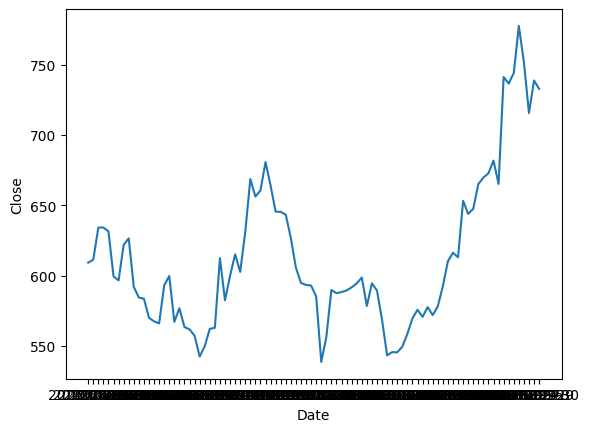

In [14]:
import seaborn as sns
class PlotChartInput(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  days : int = Field(description="Number of days for which data is to be plotted")

@tool(args_schema=PlotChartInput)
def plot_chart(ticker: str, days: int = 90) -> str:
    """Plot the closing price of a stock."""

    ticker = ticker.strip().upper()

    sub = df[df["Ticker"] == ticker].tail(days).copy()

    if sub.empty:
      return f"No data available for {ticker}"
    else:
      sns.lineplot(data = sub, x = 'Date', y = 'Close')
    return f"Displayed {ticker} price chart for the last {days} trading days."
result = plot_chart.invoke({
    "ticker": "META",
    "days": 90
})

In [15]:
class sortino(BaseModel):
  ticker : str = Field(description ="Stock symbol, e.g. 'AAPL'. NSE stocks need .NS' (e.g. 'TCS.NS'), BSE needs '.BO'.",default = None)
  days: int = Field(
        description="Number of recent trading days to use.",
        default=252
    )
@tool(args_schema=sortino)
def sharpe_sortino(ticker : str,days: int) -> str:
  """Returns how much money you get for amount of risk taken"""

  ticker = ticker.strip().upper()

  sub = df[df["Ticker"] == ticker].tail(days+1).copy()

  if sub.empty:
    return f"No data available for {ticker}"

  else:
    returns = sub['Close'].pct_change().dropna()
    average_return = returns.mean()
    downside = returns[returns < 0]
    downside_deviation = downside.std()
    sortino = average_return / downside_deviation
    return str(sortino)

result = sharpe_sortino.invoke({
    "ticker": "META",
    "days": 252
})

print(result)

0.01650207272434911


In [16]:
from sklearn.linear_model import LinearRegression


class BetaAlphaInput(BaseModel):
    ticker: str = Field(
        description="Stock symbol, e.g. 'AAPL'"
    )
    benchmark: str = Field(
        description="Benchmark symbol, e.g. 'SPY'"
    )


@tool(args_schema=BetaAlphaInput)
def beta_alpha(ticker: str, benchmark: str) -> str:
    """Calculate alpha and beta of a stock relative to a benchmark."""

    ticker = ticker.strip().upper()
    benchmark = benchmark.strip().upper()

    stock = df[df["Ticker"] == ticker][["Date", "Close"]].copy()
    market = df[df["Ticker"] == benchmark][["Date", "Close"]].copy()

    if stock.empty:
        return f"No data available for {ticker}"

    if market.empty:
        return f"No data available for benchmark {benchmark}"

    stock = stock.rename(columns={"Close": "Stock_Close"})
    market = market.rename(columns={"Close": "Benchmark_Close"})

    data = pd.merge(
        stock,
        market,
        on="Date",
        how="inner"
    )
    data["Stock_Return"] = data["Stock_Close"].pct_change()
    data["Benchmark_Return"] = data["Benchmark_Close"].pct_change()

    data = data.dropna()

    if len(data) < 2:
        return "Not enough return data to calculate alpha and beta."

    X = data[["Benchmark_Return"]]

    y = data["Stock_Return"]

    model = LinearRegression()
    model.fit(X, y)

    beta = model.coef_[0]
    alpha = model.intercept_

    return (
        f"Ticker: {ticker}\n"
        f"Benchmark: {benchmark}\n"
        f"Alpha: {alpha:.6f}\n"
        f"Beta: {beta:.4f}"
    )
result = beta_alpha.invoke({
    "ticker": "AAPL",
    "benchmark": "META"
})

print(result)

Ticker: AAPL
Benchmark: META
Alpha: 0.000585
Beta: 0.2703


In [17]:
import sqlite3
import pandas as pd
from langchain_core.tools import tool
from pydantic import BaseModel, Field

df = pd.read_csv("market_agent_data.csv")
print(df.shape)
df.head()

(12550, 10)


,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return_%,SMA_20,SMA_50
0,2021-09-30,AAPL,140.121804,140.824073,137.800417,138.014999,89056700,NaN,NaN,NaN
1,2021-09-30,AMZN,165.800003,166.392502,163.699493,164.251999,56848000,NaN,NaN,NaN
2,2021-09-30,GOOGL,132.995961,134.264877,132.297106,132.415970,37996000,NaN,NaN,NaN
3,2021-09-30,JPM,147.291254,147.353029,143.646912,144.441086,13161200,NaN,NaN,NaN
4,2021-09-30,META,337.220230,339.547911,334.942031,336.170288,16547100,NaN,NaN,NaN


In [18]:
df = df.rename(columns={"Daily_Return_%": "daily_return_pct"})   # '%' breaks unquoted SQL
df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")  # ISO text sorts correctly

DB_PATH = "market_agent.db"
conn = sqlite3.connect(DB_PATH)
df.to_sql("market_data", conn, if_exists="replace", index=False)
conn.execute("CREATE INDEX IF NOT EXISTS idx_ticker_date ON market_data (Ticker, Date)")
conn.commit()
conn.close()
print("Database built:", DB_PATH)

Database built: market_agent.db


In [19]:
ro_conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True, check_same_thread=False)

def table_names() -> set:
    rows = ro_conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
    return {r[0] for r in rows}

def clean_select(query: str):
    """Return (clean_query, error). Allows exactly one SELECT statement."""
    q = query.strip().rstrip(";").strip()
    if not q.lower().startswith("select"):
        return None, "Only SELECT statements are allowed."
    if ";" in q:
        return None, "Only a single statement is allowed (no ';')."
    return q, None

print(table_names())

{'market_data'}


In [20]:
@tool
def list_tables() -> str:
    """List all tables in the stock database. Call this first."""
    return ", ".join(sorted(table_names()))


class SchemaInput(BaseModel):
    table: str = Field(description="Table name, e.g. 'market_data'")


@tool(args_schema=SchemaInput)
def get_schema(table: str) -> str:
    """Get column names, types and 3 sample rows for a table. Call before writing SQL."""
    table = table.strip()
    if table not in table_names():
        return f"Unknown table '{table}'. Available: {', '.join(sorted(table_names()))}"
    cols = pd.read_sql_query(f"PRAGMA table_info({table})", ro_conn)[["name", "type"]]
    sample = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3", ro_conn)
    return f"Columns:\n{cols.to_string(index=False)}\n\nSample rows:\n{sample.to_string(index=False)}"

In [21]:
class QueryInput(BaseModel):
    query: str = Field(description="A single SQLite SELECT statement.")


@tool(args_schema=QueryInput)
def check_sql(query: str) -> str:
    """Validate a SELECT query WITHOUT running it. Returns 'OK' or the error to fix."""
    q, err = clean_select(query)
    if err:
        return err
    try:
        ro_conn.execute(f"EXPLAIN {q}")
        return "OK"
    except Exception as e:
        return f"SQL error: {e}"


@tool(args_schema=QueryInput)
def execute_sql(query: str) -> str:
    """Run one read-only SQLite SELECT on market_data and return at most 50 rows.
    Columns: Date (YYYY-MM-DD text), Ticker, Open, High, Low, Close, Volume,
    daily_return_pct, SMA_20, SMA_50. Use aggregates (AVG, MAX, GROUP BY) instead of
    selecting raw history. Good for filtering, ranking and aggregation, not for RSI/MACD."""
    q, err = clean_select(query)
    if err:
        return err
    try:
        out = pd.read_sql_query(f"SELECT * FROM ({q}) LIMIT 50", ro_conn)
    except Exception as e:
        return f"SQL error: {e}"
    return out.to_string(index=False) if not out.empty else "Query returned no results."

In [22]:
def load_prices(ticker: str, days: int) -> pd.DataFrame:
    q = "SELECT Date, Close FROM market_data WHERE Ticker = ? ORDER BY Date DESC LIMIT ?"
    out = pd.read_sql_query(q, ro_conn, params=(ticker, days + 1))
    return out.sort_values("Date").reset_index(drop=True)


class VolInput(BaseModel):
    ticker: str = Field(description="Stock symbol, e.g. 'AAPL'")
    window: int = Field(default=30, ge=2, le=1000, description="Number of recent trading days")


@tool(args_schema=VolInput)
def volatility_sql(ticker: str, window: int = 30) -> str:
    """Annualised volatility (std of daily returns x sqrt(252)) over the last `window`
    trading days, with prices loaded from the database."""
    symbol = ticker.strip().upper()
    px = load_prices(symbol, window)
    if len(px) < 3:
        return f"Not enough data for '{symbol}'. Use list_tables / execute_sql to see valid tickers."
    vol = px["Close"].pct_change().dropna().std() * 252 ** 0.5
    return f"{symbol} annualised volatility over last {window} trading days: {vol:.2%}"

In [23]:
print(list_tables.invoke({}), "\n")
print(get_schema.invoke({"table": "market_data"}), "\n")
print(get_schema.invoke({"table": "nope"}), "\n")

print(execute_sql.invoke({"query": """
    SELECT Ticker, ROUND(AVG(Close), 2) AS avg_close
    FROM market_data GROUP BY Ticker ORDER BY avg_close DESC
"""}), "\n")

# 1-year return per ticker (self-join)
print(execute_sql.invoke({"query": """
    SELECT a.Ticker, ROUND((b.Close / a.Close - 1) * 100, 2) AS return_1y_pct
    FROM market_data a JOIN market_data b ON a.Ticker = b.Ticker
    WHERE a.Date = (SELECT MIN(Date) FROM market_data WHERE Date >= '2025-09-30')
      AND b.Date = (SELECT MAX(Date) FROM market_data)
    ORDER BY return_1y_pct DESC
"""}), "\n")

# safety checks: all should be refused or error cleanly
print(execute_sql.invoke({"query": "DROP TABLE market_data"}))
print(execute_sql.invoke({"query": "SELECT 1; DELETE FROM market_data"}))
print(execute_sql.invoke({"query": "SELECT * FROM missing_table"}))
print(check_sql.invoke({"query": "SELECT Ticker FROM market_data"}), "\n")

print(volatility_sql.invoke({"ticker": "META", "window": 30}))
print(volatility_sql.invoke({"ticker": "XYZ", "window": 30}))

market_data 

Columns:
            name    type
            Date    TEXT
          Ticker    TEXT
            Open    REAL
            High    REAL
             Low    REAL
           Close    REAL
          Volume INTEGER
daily_return_pct    REAL
          SMA_20    REAL
          SMA_50    REAL

Sample rows:
      Date Ticker       Open       High        Low      Close   Volume daily_return_pct SMA_20 SMA_50
2021-09-30   AAPL 140.121804 140.824073 137.800417 138.014999 89056700             None   None   None
2021-09-30   AMZN 165.800003 166.392502 163.699493 164.251999 56848000             None   None   None
2021-09-30  GOOGL 132.995961 134.264877 132.297106 132.415970 37996000             None   None   None 

Unknown table 'nope'. Available: market_data 

Ticker  avg_close
  META     431.65
  MSFT     367.30
  TSLA     288.59
     V     269.54
  AAPL     202.56
   JPM     199.22
 GOOGL     178.74
  AMZN     174.75
  NVDA      94.51
  NFLX      64.58 

Ticker  return_1y_pct
 GOOGL   

In [24]:
sql_tools = [list_tables, get_schema, check_sql, execute_sql, volatility_sql]
print([t.name for t in sql_tools])

['list_tables', 'get_schema', 'check_sql', 'execute_sql', 'volatility_sql']


In [25]:
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 33 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 1s (583 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 127332 files and directories currently installed.)
Preparing to unpack .../zstd_1.5.5+dfsg2-2build1.1_amd64.deb ...
Unpacking zstd (1.5.5+dfsg2-2build1.1) ...
Setting up zstd (1.5.5+dfsg2-2build1.1) ...
Processing triggers for man-db (2.12.0-4build2) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video grou

In [26]:
import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)
!ollama pull qwen3:8b

In [27]:
!pip install -q langchain-ollama


In [28]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="qwen3:8b", temperature=0)   # temperature=0 = more consistent tool choice

In [29]:
all_tools = [
    # Stage 1 (pandas) - names must match your @tool function names
    get_market_data, daily_returns, moving_average, summary_stats,
    volatility, rsi, macd, envelope, compare_tickers, correlation_matrix,
    plot_chart, sharpe_sortino, beta_alpha,
    # Stage 2 (SQL)
    list_tables, get_schema, check_sql, execute_sql,
]



In [30]:
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

tool_map = {t.name: t for t in all_tools}
agent_llm = llm.bind_tools(all_tools)

TICKERS = sorted(df["Ticker"].unique())
SYSTEM = f"""You are a stock market data analyst. Data covers ONLY these tickers: {', '.join(TICKERS)}
(daily, {df['Date'].min()} to {df['Date'].max()}).
Rules:
- Every number must come from a tool; never guess or combine numbers from different tools.
- Single-ticker tools cannot compare or rank tickers. For rankings or questions across all
  tickers, use execute_sql (call get_schema first if unsure of columns).
- Volatility is annualised; report it as a percentage.
- RSI: above 70 overbought, below 30 oversold, 30-70 neutral.
- Analysis only, no buy/sell advice."""

def run_agent(question: str, max_steps: int = 6):
    messages = [SystemMessage(SYSTEM), HumanMessage(question)]
    for _ in range(max_steps):
        ai = agent_llm.invoke(messages)
        messages.append(ai)
        if not ai.tool_calls:
            return ai.content, messages
        for call in ai.tool_calls:
            tool = tool_map.get(call["name"])
            try:
                out = tool.invoke(call["args"]) if tool else f"Unknown tool {call['name']}"
            except Exception as e:
                out = f"Tool error: {e}"
            messages.append(ToolMessage(content=str(out), tool_call_id=call["id"]))
    return "Stopped: too many steps.", messages

In [31]:
def ask(q):
    answer, msgs = run_agent(q)
    used = [c["name"] for m in msgs if getattr(m, "tool_calls", None) for c in m.tool_calls]
    print("Q:", q, "\nTools used:", used, "\nA:", answer, "\n")

ask("Which was more volatile over the last 30 days, META or AAPL?")
ask("What is META's RSI over 14 days?")
ask("Which ticker had the highest average close?")

Q: Which was more volatile over the last 30 days, META or AAPL? 
Tools used: ['volatility', 'volatility'] 
A: META was more volatile than AAPL over the last 30 days. Its annualized volatility was **47.09%** versus AAPL's **22.83%**. This means META's price fluctuated more widely relative to its average over this period. 

Q: What is META's RSI over 14 days? 
Tools used: ['rsi'] 
A: META's 14-day Relative Strength Index (RSI) is **66.65**, indicating it is in the **overbought** range (above 70). While not yet exceeding the classic overbought threshold, this suggests strong upward momentum and potential for a pullback. Traders often watch for RSI to cross above 70 as a sell signal. 

Note: RSI is a momentum oscillator, and this value reflects buying pressure relative to recent price changes. 

Q: Which ticker had the highest average close? 
Tools used: ['execute_sql'] 
A: The ticker with the highest average closing price is **META** at an average of **$431.65**. 

